### import libraries

In [13]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
from XLO_sim.XLO_sim import XLO_sim
from XLO_sim.Plot import XLO_plot
from XLO_sim import tools

import numpy.fft as fft

import scipy.constants as sp_const
au_in_eV = sp_const.value('atomic unit of energy') / sp_const.value('atomic unit of charge')

import multiprocess as mp
import shutil

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)

### Transmission

In [14]:
tpad = 1000
xpad = 64
ypad = 64

th_show = 2
w_show = 5

thx_show_min = -th_show
thx_show_max = th_show
thy_show_min = -th_show
thy_show_max = th_show
w_show_min = -w_show
w_show_max = w_show

   
def FFT_w_thy(X, field_pstxy):
    coeffs = (2.0 * np.pi * X.hbar, 2.0 * np.pi / X.k0)
    shifts = (X.t_pump_max + tpad * X.dt, X.ymax + ypad * X.dy)
    field_psxty = np.einsum('pstxy->psxty',field_pstxy)
    pad_shape = [(0, 0), (0, 0), (0, 0), (tpad, tpad), (ypad, ypad)]
    domains_sim, meshes_sim, step_sizes_sim = X.optics.nd_kspace(coeffs, (X.tgrid, X.ygrid), (tpad, ypad), (X.dt, X.dy))
    phasors = [np.exp(1j * 2.0 * np.pi * mesh * shift / coeff) for coeff, mesh, shift in zip(coeffs, meshes_sim, shifts)]

    field_psxty_pad = X.optics.my_pad(field_psxty, pad_shape)
    field_fft_pad_phased = X.optics.my_fft_phased(field_psxty_pad, (3, 4), phasors)

    extent_w_thy = [
        np.min(domains_sim[0][tpad:X.tgrid + tpad]), np.max(domains_sim[0][tpad:X.tgrid + tpad]),
        1e3*np.min(domains_sim[1]), 1e3*np.max(domains_sim[1])]

    return extent_w_thy, field_fft_pad_phased 



def I_w(X, zint, isPlot):
    OmegaSF_z_pstxy = X.Omega_pstxyz[:, :, :, :, :, zint]
    extent_w_thy, OmegaSF_z_psxwThy = FFT_w_thy(X, OmegaSF_z_pstxy) 
    I_SF_w_thy = np.real(
        np.einsum('sxwy,sxwy->wy', OmegaSF_z_psxwThy[0,:,:,:,:], OmegaSF_z_psxwThy[1,:,:,::-1,::-1])
    )  

    ygrid_pad = X.ygrid + 2*ypad
    tgrid_pad = X.tgrid + 2*tpad
    womega_ar  = np.linspace(extent_w_thy[0], extent_w_thy[1], tgrid_pad)
    theta_y_ar = np.linspace(extent_w_thy[2], extent_w_thy[3], ygrid_pad)

    dtheta_y = theta_y_ar[1] - theta_y_ar[0] 
    I_int_thy_w = np.real(dtheta_y * np.einsum('wa -> w', I_SF_w_thy))
    I_thy0_w = np.real(I_SF_w_thy[:,int(ygrid_pad/2)])
    
    if isPlot:
        plt.figure()
        plt.plot(womega_ar, I_int_thy_w,'-', label = 'int thy')
        plt.plot(womega_ar, I_thy0_w/max(I_thy0_w) * max(I_int_thy_w),'--', label = 'thy=0')
        plt.ylabel(r'$\int d \theta_y I(\omega,\theta_y$) ')
        plt.xlabel(r'$\omega$ (eV)')
        plt.xlim(w_show_min, w_show_max)
        plt.legend()
        plt.show()
        
    return womega_ar, I_int_thy_w, I_thy0_w 


In [15]:
def yaml_modify_seed_energy(input_yaml_path, output_yaml_path, new_seed_energy):
    # Read the original YAML file
    with open(input_yaml_path, 'r') as file:
        yaml_data = yaml.safe_load(file)
    
    # Modify the seed energy value
    yaml_data['E_seed_uJ'] = new_seed_energy
    
    # Write the modified data to a new YAML file
    with open(output_yaml_path, 'w') as file:
        yaml.safe_dump(yaml_data, file)
    
    print(f"Modified YAML file saved to {output_yaml_path}")


In [ ]:
ar_Eseed_values = [40, 20, 10, 5, 1, 0.1]
ar_yaml = []

for Eseed in ar_Eseed_values:
    input_yaml_path = notebook_directory + '/config/Cu-seed-SASE.yaml'
    output_yaml_path = notebook_directory + '/config/Cu-seed-SASE_' + f'{Eseed:.2f}' + 'uJ.yaml'
    yaml_modify_seed_energy(input_yaml_path, output_yaml_path, Eseed)
    ar_yaml.append(output_yaml_path)


Modified YAML file saved to /Users/parkinpham/Programming/Physics/DESY_Internship/XLO_sim_related_notebook/config/Cu-seed_40.00uJ.yaml
Modified YAML file saved to /Users/parkinpham/Programming/Physics/DESY_Internship/XLO_sim_related_notebook/config/Cu-seed_20.00uJ.yaml
Modified YAML file saved to /Users/parkinpham/Programming/Physics/DESY_Internship/XLO_sim_related_notebook/config/Cu-seed_10.00uJ.yaml
Modified YAML file saved to /Users/parkinpham/Programming/Physics/DESY_Internship/XLO_sim_related_notebook/config/Cu-seed_5.00uJ.yaml
Modified YAML file saved to /Users/parkinpham/Programming/Physics/DESY_Internship/XLO_sim_related_notebook/config/Cu-seed_1.00uJ.yaml
Modified YAML file saved to /Users/parkinpham/Programming/Physics/DESY_Internship/XLO_sim_related_notebook/config/Cu-seed_0.10uJ.yaml


### calculating for given amount of repetitions for each yaml

In [ ]:
nrep = 10

# Get the number of available CPU cores
num_cpus = mp.cpu_count()

# Set the maximum number of processes to use
num_processes = num_cpus - 1  # Leave one core for system processes or other tasks
print("num_processes", num_processes)

   
data_path = os.path.join(notebook_directory, 'data/' + np.datetime_as_string(np.datetime64('now')))
if not os.path.exists(data_path):
    os.makedirs(data_path)

def run_simulation(yaml, run_path, rep):
    print('repetition ', rep + 1)

    X = XLO_sim(yaml)
    seed_field = tools.Ocelot_SASE_seed_pstxy(X)
    X.configure(seed_field)
    X.run_3D()

    womega_ar, I_int_thy_w_0, I_thy0_w_0 = I_w(X, 0, False)
    womega_ar, I_int_thy_w_last, I_thy0_w_last = I_w(X, -1, False)

    date_string = np.datetime_as_string(np.datetime64('now'))
    np.savez_compressed(
        os.path.join(run_path, f"run_at_seed_{X.E_seed_uJ:.1f}_uJ__repetition_{rep + 1}_{date_string}.npz"),
        womega_ar=womega_ar,
        I_int_thy_w_0=I_int_thy_w_0,
        I_thy0_w_0=I_thy0_w_0,
        I_int_thy_w_last=I_int_thy_w_last,
        I_thy0_w_last=I_thy0_w_last
    )

def run_repetitions_from_yaml(yaml, nrep, num_processes, data_path):
    date_string = np.datetime_as_string(np.datetime64('now'))
    X = XLO_sim(yaml)

    run_path = os.path.join(data_path, f'runs_seed_{X.E_seed_uJ:.1f}_uJ_{date_string}')
    if not os.path.exists(run_path):
        os.makedirs(run_path)

    shutil.copy2(yaml, run_path)

    # Create a pool of processes
    with mp.Pool(processes=num_processes) as pool:
        # Run simulations in parallel
        pool.starmap(run_simulation, [(yaml, run_path, rep) for rep in range(nrep)])

if __name__ == '__main__':
    for yaml_value in ar_yaml:
        run_repetitions_from_yaml(yaml_value, nrep, num_processes, data_path)

num_processes 1


"scale_kz" will be deprecated, use "grid_z and grid_kz" instead


number of pump photons = 7.8e+05
Ocelot_SASE_pulse_pump_txy
repetition  1
number of pump photons = 7.8e+05


"scale_kz" will be deprecated, use "grid_z and grid_kz" instead


Ocelot_SASE_pulse_pump_txy
repetition  4
number of pump photons = 7.8e+05


...

"scale_kz" will be deprecated, use "grid_z and grid_kz" instead


Ocelot_SASE_pulse_pump_txy
repetition  10
number of pump photons = 7.8e+05


"scale_kz" will be deprecated, use "grid_z and grid_kz" instead


Ocelot_SASE_pulse_pump_txy


AttributeError: 'XLO_sim' object has no attribute 'seed_FEL_bandwidth'

### reading and plotting

In [ ]:
figs_path = os.path.join(notebook_directory, 'figs')
if not os.path.exists(figs_path):
    os.makedirs(figs_path)

In [ ]:
from collections import OrderedDict


def data_from_folder(folder_path):

    # print(os.listdir(folder_path))

    # Initialize the top-level dictionary to store accumulated arrays for each E_seed
    accumulated_arrays = {}

    for runs_Eseed_folder in os.listdir(folder_path):
        # Specify the path to the folder containing the saved files
        runs_path = folder_path + '/' + runs_Eseed_folder

        # Find the YAML file in the folder
        yaml_file = None
        for file_name in os.listdir(runs_path):
            if file_name.endswith('.yaml'):
                yaml_file = os.path.join(runs_path, file_name)
                break

        if yaml_file is None:
            print(f"No YAML file found in {runs_path}")
            continue

        # Read the YAML file to get the E_seed value
        with open(yaml_file, 'r') as f:
            yaml_data = yaml.safe_load(f)
            E_seed_value = yaml_data['E_seed_uJ']
            
            # seed_FEL_bandwidth = yaml_data['seed_FEL_bandwidth']
            tgrid = yaml_data['tgrid']
            xgrid = yaml_data['xgrid']
            ygrid = yaml_data['ygrid']
            zgrid = yaml_data['zgrid']
            sigma1_Ka1_2p3 = yaml_data['sigma1_Ka1_2p3']
            sigma1_Ka1_other = yaml_data['sigma1_Ka1_other']
            seed_duration_FWHM_t = yaml_data['seed_duration_FWHM_t']
            
            aux_data = [tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t]

        # Initialize variables to store the accumulated arrays for the current E_seed
        if E_seed_value not in accumulated_arrays:
            accumulated_arrays[E_seed_value] = {}

        # Iterate over all files in the folder
        for file_name in os.listdir(runs_path):
            # Check if the file is a numpy savez_compressed file
            if file_name.endswith('.npz'):
                # Load the file
                file_path = os.path.join(runs_path, file_name)
                data = np.load(file_path)

                # Iterate over all arrays in the loaded file
                for array_name in data.files:
                    # Accumulate the arrays by averaging them
                    if array_name in accumulated_arrays[E_seed_value]:
                        accumulated_arrays[E_seed_value][array_name] += data[array_name]
                    else:
                        accumulated_arrays[E_seed_value][array_name] = data[array_name]

        # Divide each accumulated array by the number of files to get the average
        num_files = len([file_name for file_name in os.listdir(runs_path) if file_name.endswith('.npz')])
        # print(f'E_seed: {E_seed_value}, num_files: {num_files}')
        for array_name in accumulated_arrays[E_seed_value]:
            accumulated_arrays[E_seed_value][array_name] /= num_files

    # Sort the accumulated arrays by E_seed value
    sorted_accumulated_arrays = OrderedDict(sorted(accumulated_arrays.items(), key=lambda x: x[0], reverse=True))

    # Example of how to access the accumulated arrays for a specific E_seed
    # for E_seed_value, arrays in sorted_accumulated_arrays.items():
    #     print(f'E_seed: {E_seed_value}')
    #     for array_name, array_data in arrays.items():
    #         print(f'  Array name: {array_name}, shape: {array_data.shape}')
    
    return sorted_accumulated_arrays, aux_data, num_files

E_seed: 40
E_seed: 20
E_seed: 10
E_seed: 5
E_seed: 1
E_seed: 0.1


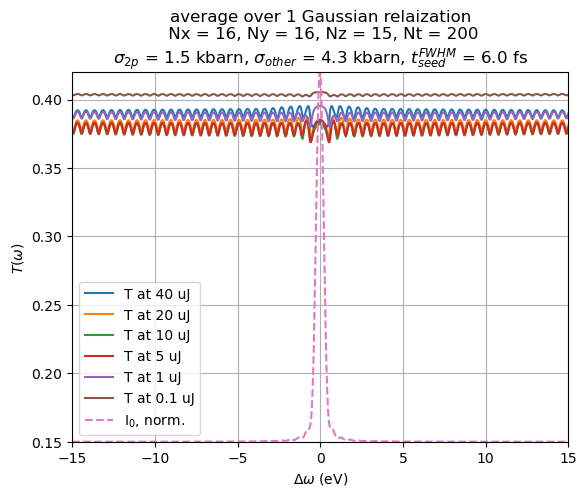

In [ ]:
Tshow_min = 0.15#0.4
Tshow_max = 0.42#0.5

def plotting_data_folder(folder_path, Tshow_min, Tshow_max):
    
    sorted_accumulated_arrays, aux_data, num_files = data_from_folder(folder_path)
    
    tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t = aux_data

    plt.figure()
    
    str_pars_grid = " Nx = " + str(xgrid) + ", Ny = " + str(ygrid) + ", Nz = " + str(zgrid) + ", Nt = " + str(tgrid)
    str_pars_calc = r'$\sigma_{2p}$ = ' + f'{1e7*sigma1_Ka1_2p3:.1f}' + ' kbarn' + \
    r', $\sigma_{other}$ = ' + f'{1e7*sigma1_Ka1_other:.1f}' +' kbarn' + \
    r', $t_{seed}^{FWHM}$ = ' + f'{seed_duration_FWHM_t:.1f}' +' fs'
    
    plt.title('average over ' + str(num_files) + ' Gaussian relaization' + '\n'
    + str_pars_grid + '\n' + str_pars_calc
     )          
             


    for E_seed_value, arrays in sorted_accumulated_arrays.items():
        print(f'E_seed: {E_seed_value}')
        # for array_name, array_data in arrays.items():
        #     print(f'  Array name: {array_name}, shape: {array_data.shape}')

        womega_ar = arrays['womega_ar']
        I_int_thy_w_last = arrays['I_int_thy_w_last']
        I_int_thy_w_0 = arrays['I_int_thy_w_0']
        
        I_int_thy_w_last = I_int_thy_w_last + 0.00001 * max(I_int_thy_w_last)
        I_int_thy_w_0 = I_int_thy_w_0 + 0.00001 * max(I_int_thy_w_0)
        
        Tint_w = I_int_thy_w_last / I_int_thy_w_0
        
        T0_w = arrays['I_thy0_w_last'] / arrays['I_thy0_w_0']
        # plt.plot(womega_ar, arrays['I_int_thy_w_last'], label = 'I(z=L)' + str(E_seed_value) + ' uJ')
        # plt.plot(womega_ar, arrays['I_int_thy_w_0'], label = 'I(z=0)' + str(E_seed_value) + ' uJ')
        
        plt.plot(womega_ar, Tint_w, label = 'T at '+ str(E_seed_value) + ' uJ')
    plt.plot(womega_ar, Tshow_min + (Tshow_max-Tshow_min) * arrays['I_int_thy_w_0']/max(arrays['I_int_thy_w_0']),'--', label = r'I$_0$, norm.')
    plt.ylabel(r'$T(\omega$) ')
    plt.xlabel(r'$\Delta\omega$ (eV)')
    plt.xlim(w_show_min, w_show_max)
    plt.ylim(Tshow_min,Tshow_max)
    plt.legend()
    plt.grid(True)
    # plt.yscale('log')
    plt.savefig(figs_path + '/' + str_pars_calc + '.pdf')
    plt.show()
    
plotting_data_folder(data_path, Tshow_min, Tshow_max)
